In [1]:
import pandas as pd

df=pd.read_csv('../datasets/processed/DSGP1.csv')
df.head()

,T2M,T2M_RANGE,RH2M,GWETTOP,Cluster_Label,PCACOMP1,PCACOMP2,PCACOMP3
0,24.166667,6.551333,77.967333,0.587333,1,-1.780082,-0.433574,-1.627375
1,24.581667,5.710000,79.531667,0.565000,1,-1.479069,-0.312703,-0.859869
2,24.756000,6.982000,80.534000,0.611000,1,-1.336950,-0.412495,-0.381413
3,25.878333,8.392500,71.654167,0.480000,0,-1.730179,-0.101366,-1.368670
4,27.590000,7.645000,72.365000,0.433333,0,-1.080854,-0.187889,0.928905


In [3]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.combine import SMOTETomek
from sklearn.metrics import accuracy_score
from collections import Counter


X = df.drop(["Cluster_Label"], axis=1)
Y = df["Cluster_Label"]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train, y_train)
print("Class distribution after SMOTETomek:", Counter(y_train_resampled))


rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [200, 250, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [5, 10, 15],
    'max_features': ['sqrt', 'log2'],
}


grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

grid_search.fit(X_train_resampled, y_train_resampled)


print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train_resampled)
y_val_pred = best_model.predict(X_test)

training_accuracy = accuracy_score(y_train_resampled, y_train_pred)
validation_accuracy = accuracy_score(y_test, y_val_pred)

print(f"Training Accuracy: {training_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {validation_accuracy * 100:.2f}%")


Class distribution after SMOTETomek: Counter({1: 403, 0: 403})
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
Training Accuracy: 99.50%
Validation Accuracy: 99.48%


In [4]:
X.head()

,T2M,T2M_RANGE,RH2M,GWETTOP,PCACOMP1,PCACOMP2,PCACOMP3
0,24.166667,6.551333,77.967333,0.587333,-1.780082,-0.433574,-1.627375
1,24.581667,5.710000,79.531667,0.565000,-1.479069,-0.312703,-0.859869
2,24.756000,6.982000,80.534000,0.611000,-1.336950,-0.412495,-0.381413
3,25.878333,8.392500,71.654167,0.480000,-1.730179,-0.101366,-1.368670
4,27.590000,7.645000,72.365000,0.433333,-1.080854,-0.187889,0.928905


In [5]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_val_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        81
           1       0.99      1.00      1.00       112

    accuracy                           0.99       193
   macro avg       1.00      0.99      0.99       193
weighted avg       0.99      0.99      0.99       193



In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier()
scores = cross_val_score(rf_classifier, X, Y, cv=5, scoring='f1_macro')
print("Cross-Validation F1-Scores:", scores)
print("Mean F1-Score:", scores.mean())

Cross-Validation F1-Scores: [0.9896348  0.9740682  0.98445596 0.99481865 0.97927405]
Mean F1-Score: 0.9844503339286295


In [7]:
from sklearn.preprocessing import StandardScaler



X=df.drop(['Cluster_Label'],axis=1)

scaler=StandardScaler()
X_scale=scaler.fit_transform(X)
Scaled_df=pd.DataFrame(X_scale,columns=X.columns)
Scaled_df.head()

,T2M,T2M_RANGE,RH2M,GWETTOP,PCACOMP1,PCACOMP2,PCACOMP3
0,-1.792869,-0.070642,-0.015286,0.051606,-1.780082,-0.433574,-1.627375
1,-1.506076,-0.484933,0.185296,-0.073296,-1.479069,-0.312703,-0.859869
2,-1.385600,0.141427,0.313818,0.183966,-1.336950,-0.412495,-0.381413
3,-0.609990,0.835988,-0.824773,-0.548671,-1.730179,-0.101366,-1.368670
4,0.572889,0.467903,-0.733629,-0.809661,-1.080854,-0.187889,0.928905


In [8]:
df1 = pd.concat([df['Cluster_Label'], Scaled_df], axis=1)
df1.head()

,Cluster_Label,T2M,T2M_RANGE,RH2M,GWETTOP,PCACOMP1,PCACOMP2,PCACOMP3
0,1,-1.792869,-0.070642,-0.015286,0.051606,-1.780082,-0.433574,-1.627375
1,1,-1.506076,-0.484933,0.185296,-0.073296,-1.479069,-0.312703,-0.859869
2,1,-1.385600,0.141427,0.313818,0.183966,-1.336950,-0.412495,-0.381413
3,0,-0.609990,0.835988,-0.824773,-0.548671,-1.730179,-0.101366,-1.368670
4,0,0.572889,0.467903,-0.733629,-0.809661,-1.080854,-0.187889,0.928905


In [9]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)  # Gini Impurity
dt_model.fit(X_train_resampled, y_train_resampled)

y_pred = dt_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9896373056994818
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        81
           1       0.99      0.99      0.99       112

    accuracy                           0.99       193
   macro avg       0.99      0.99      0.99       193
weighted avg       0.99      0.99      0.99       193



In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Input
from sklearn.model_selection import train_test_split

X=df1.drop('Cluster_Label',axis=1)
Y=df1['Cluster_Label']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train, y_train)


model = Sequential([
    Input(shape=(7,)),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(16, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_resampled, y_resampled, validation_data=(X_test, y_test), epochs=30, batch_size=64)

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_pred=model.predict(X_test)
 
y_pred_labels = (y_pred > 0.5).astype(int)  
print(classification_report(y_test, y_pred_labels))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        81
           1       0.99      1.00      1.00       112

    accuracy                           0.99       193
   macro avg       1.00      0.99      0.99       193
weighted avg       0.99      0.99      0.99       193



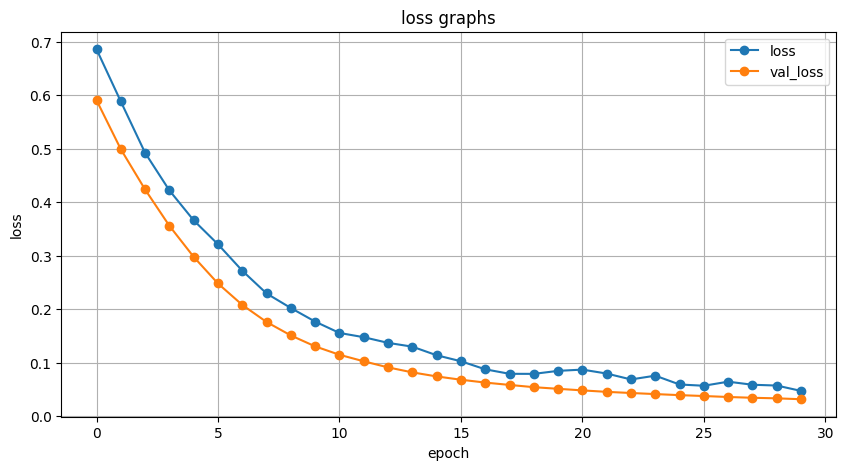

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='loss', marker='o')
plt.plot(history.history['val_loss'], label='val_loss',marker='o')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title("loss graphs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pickle
with open('irrigation_optimization_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)